In [3]:
import pandas as pd
df = pd.read_csv("bmw.csv")

In [12]:
df.head(), df.shape, df.info()
df["price"].value_counts()
#regression type dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


,count
price,
20980,45
15000,43
14000,40
18000,37
29995,36
...,...
5678,1
24100,1
15390,1


In [13]:
#checking missing values
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


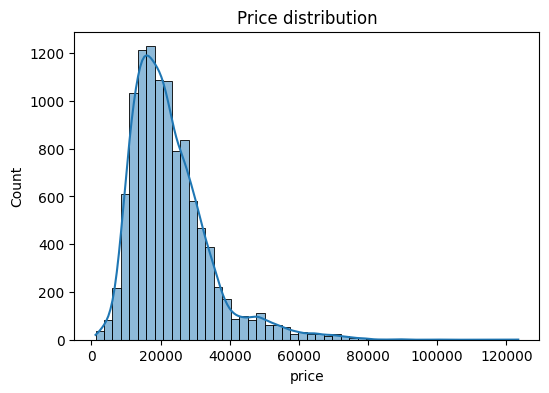

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
#single numerical variable -> histogram
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price distribution")
plt.show()
#right skew dataset

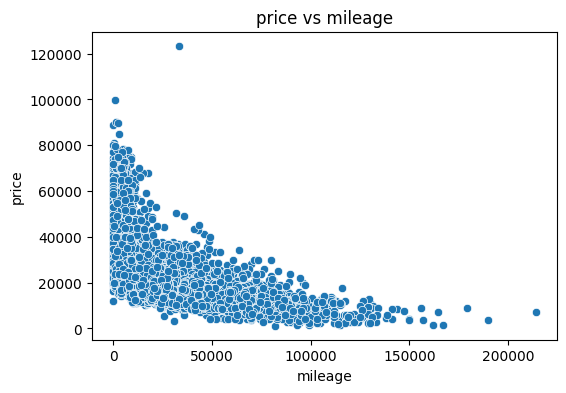

In [23]:
#price vs mileage
#Numerical vs Numerical → Scatter plot
plt.figure(figsize=(6,4))
sns.scatterplot(x='mileage', y='price', data=df)
plt.title("price vs mileage")
plt.show()
#higher mileage lower price

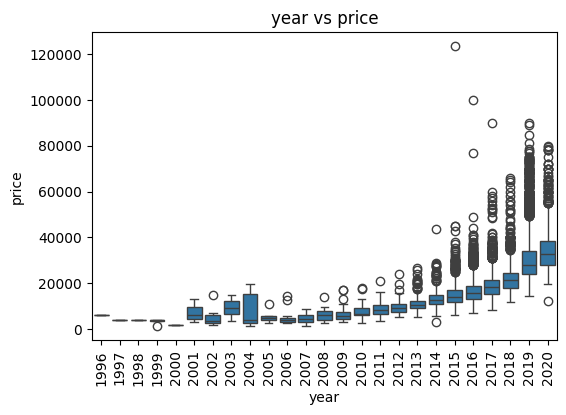

In [31]:
#price vs year comparison
#Categorical vs Numerical → Boxplot
#year behaves like category here price across years
plt.figure(figsize=(6,4))
sns.boxplot(x='year', y='price', data=df)
plt.xticks(rotation=90) #clear x scale numbers
plt.title("year vs price")
plt.show()
#newer car -> more costs

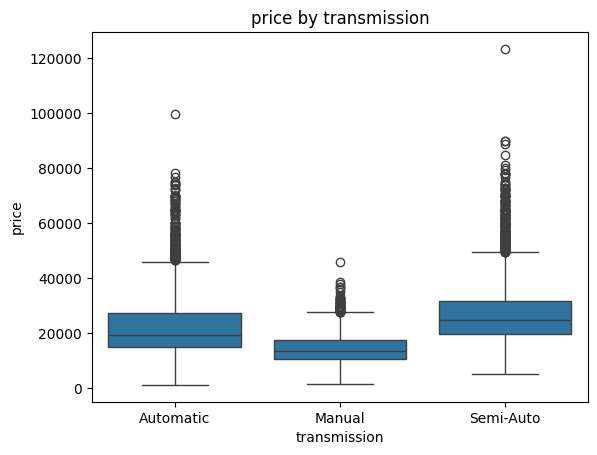

In [33]:
#categorical impacts
sns.boxplot(x='transmission', y='price', data=df)
plt.title("price by transmission")
plt.show()

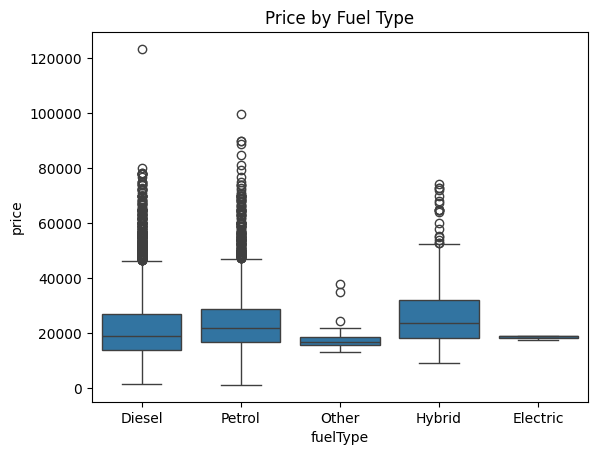

In [34]:
sns.boxplot(x='fuelType', y='price', data=df)
plt.title("Price by Fuel Type")
plt.show()


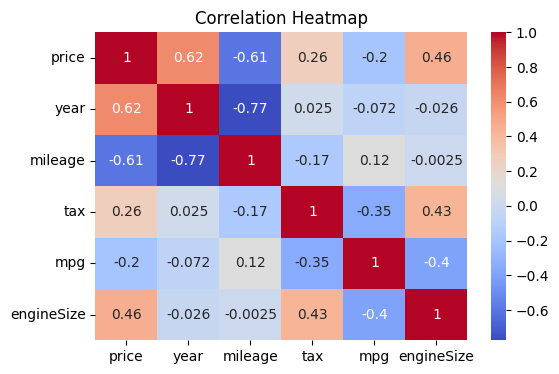

In [36]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['price','year','mileage','tax','mpg','engineSize']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#closer to +1 or -1 is strong
#closer to 0 is weak
#sign (+/-)= direction
#Positive correlation → both go up together
#Negative correlation → one goes up, the other goes down

In [40]:
X_train.dtypes

,0
model,object
year,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64


In [41]:
#one hot encoding
X = df.drop('price', axis=1)
y = df['price']

X = pd.get_dummies(X, drop_first=True)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
X_train.dtypes.unique()


array([dtype('int64'), dtype('float64'), dtype('bool')], dtype=object)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [45]:
lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [48]:
y_pred_lr = lr.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


MAE: 2821.9803760444465
RMSE: 4257.787842417521
